
# Ingest New Evolutionary Models into SEDA


Tutorial to show how users can add evolutionary model tables not in the [list of available evolutionary models](https://seda.readthedocs.io/en/latest/overview.html#evolutionary-models).


In [4]:
import seda
import numpy as np
import os
import json
import importlib  # optional: reload after writing plugin.py
import matplotlib.pyplot as plt
import shutil
from importlib import resources  # locates seda.evolution_aux/ inside the installed package
from seda.models_aux._plugin_helpers import export_plugin_function  # writes plugin.py from notebook functions
from pathlib import Path


    SEDA v0.1.dev1340 package imported


Available evolutionary models:

In [ ]:
# list all evolutionary models already registered in seda.evolution_aux/
seda.models.EvolutionaryModels().available_models

If the evolutionary models you are interested in are not listed above, you can add new models by following the steps outlined in this tutorial.

As an example, this tutorial explains how Sonora Bobcat evolutionary tables were ingested.

## 1. Create `config.json` File

First, create a JSON file containing the basic information for the models. This file will be used throughout the code and accessed via various attributes of `seda.models.EvolutionaryModels()`. To do this, define a dictionary with the required parameters by following the script below, modifying only the lines marked with the comment "fill out accordingly".

Then, save the dictionary in the directory `evolution_aux/MY_MODEL`, where `MY_MODEL` matches the model name specified below. The folder will be created if it does not already exist and will be used to store all files and materials related to the new model.

The JSON file should be saved with the name `config.json`:

In [ ]:
data = {
    "_comment_model": "Internal label for the evolutionary models",
    "model": "Sonora_Bobcat",  # fill out accordingly
    "_comment_ref": "Reference for the models (optional)",
    "ref": "Marley et al. (2021)",  # fill out accordingly
    "_comment_name": "Name of the models (optional)",
    "name": "Sonora Bobcat",  # fill out accordingly
    "_comment_bibcode": "bibcode identifier for the models (optional)",
    "bibcode": "2021ApJ...920...85M",  # fill out accordingly
    "_comment_ADS": "ADS link to the model publication (optional)",
    "ADS": "https://ui.adsabs.harvard.edu/abs/2021ApJ...920...85M/abstract",  # fill out accordingly
    "_comment_download": "Link to download the models (optional)",
    "download": "https://zenodo.org/records/5063476",  # fill out accordingly
    "_comment_filename_pattern": "Common pattern recognized in evolutionary table filenames",
    "filename_pattern": "*_mass",  # fill out accordingly
    "_comment_columns": "Columns in each evolutionary table data row (logI is parsed out and ignored for Bobcat)",
    "columns": ["mass", "age", "logL", "Teff", "logg", "radius", "logI"],  # fill out accordingly
    "_comment_units": "Units of the parsed grid quantities returned by _read_evolutionary_model",
    "units": {  # fill out accordingly
        "mass": "M_sun",
        "age": "Gyr",
        "logL": "log10(L/Lsun)",  # interpolation axis (required)
        "Teff": "K",
        "logg": "cgs dex",
        "radius": "R_sun",  # interpolation axis (required)
    },
}

# file path to save the JSON file
evolution_aux = resources.files('seda.evolution_aux')
model = data['model']
path = evolution_aux / model

# check whether the directory exist, and if not create it
if not os.path.exists(path):
    os.makedirs(path)

# file name
file = 'config.json'

# write the dictionary to a JSON file
with open(path / file, 'w') as json_file:
    json.dump(data, json_file, indent=4)

print(f"JSON file '{file}' created successfully.")

## 2. Define `_read_evolutionary_model` Function

Next, define a function (`_read_evolutionary_model`) that reads one evolutionary table file and returns a dictionary of 1D numpy arrays.

The function receives a **basename** (not a full path). Each table must provide at least `logL` and `radius` for interpolation; additional columns (e.g. `mass`, `age`, `Teff`, `logg`) are inferred by `seda.phy_params.evol_params`.

In [5]:
def _read_evolutionary_model(filename):
    """
    Read a Sonora Bobcat ``*_mass`` evolutionary table and return a dictionary of grid arrays.
    The seventh column (log I) is parsed out and not returned.
    """
    _MODEL_DIR = Path(__file__).parent
    table_path = _MODEL_DIR / filename 

    with open(table_path) as evo_file:  #replace with your reading logic if different
        rows = [line.split() for line in evo_file]

    # keep only numeric rows; skip header / track-label lines automatically
    data = np.array([row for row in rows if len(row) == 7], dtype=float)

    # keys must include L and radius; other columns are interpolated by evol_params
    out = {'mass': data[:, 0], 'age': data[:, 1], 'logL': data[:, 2],
           'Teff': data[:, 3], 'logg': data[:, 4], 'radius': data[:, 5]}

    return out

## 3. Define `_convert_inputs` Function

Define a function (`_convert_inputs`) that converts user observables passed to `seda.phy_params.evol_params` into the grid interpolation axes and their Gaussian sigmas for Monte Carlo sampling.

Users pass `Lbol` in L_sun and `R` in R_jup. For Sonora Bobcat, the function must return `logL`, `e_logL`, `radius`, and `e_radius`.

In [2]:
from astropy.constants import R_jup, R_sun

def _convert_inputs(Lbol, eLbol, R, eR):
    """
    Convert user inputs to grid interpolation-axis units.

    Users pass Lbol in L_sun and R in R_jup. Returns
    the ``logL`` and ``radius`` axes used by the evolutionary grid.
    """

    # convert radius to the native grid unit (R_sun for Sonora tables)
    R_rsun = (R * R_jup).to(R_sun).value
    eR_rsun = (eR * R_jup).to(R_sun).value

    # evol_params interpolates in logL, not linear L
    logL = np.log10(Lbol)
    e_logL = eLbol / (Lbol * np.log(10))  # Gaussian propagation e_L -> e_logL for Monte Carlo sampling

    # keys must match the interpolation axes declared in the grid (+ e_<axis> uncertainties)
    return {
        'logL': logL, 'e_logL': e_logL,
        'radius': R_rsun, 'e_radius': eR_rsun,
    }

Test the function `_convert_inputs` with example values:

In [5]:
# example observables
Lbol, eLbol = 6.324e-5, 6.978e-6  # Lsun
R, eR = 1.018, 0.059              # Rjup

# should return logL, e_logL, radius, e_radius in same units as evolutionary model
_convert_inputs(Lbol, eLbol, R, eR)

{'logL': -4.199008138739829,
 'e_logL': 0.04792072888552958,
 'radius': 0.10461241339657898,
 'e_radius': 0.006062998418858703}

Once the functions `_read_evolutionary_model` and `_convert_inputs` are implemented, run the script below to save them in the file `plugin.py` inside `evolution_aux/MY_MODEL`. If `plugin.py` already exists, it will be overwritten.

In [ ]:
# full path to the plugin.py file for the current model
plugin_path = evolution_aux / model / 'plugin.py'

# header with imports required by the plugin functions
header = '\n'.join([
    'from pathlib import Path',
    'import numpy as np',
    'from astropy.constants import R_jup, R_sun',
]) + '\n'

# write/overwrite plugin.py with both functions and the header
export_plugin_function(plugin_path, [_read_evolutionary_model, _convert_inputs], header=header)

## 4. Copy Evolutionary Table Files Into SEDA

Copy one or more table files matching `filename_pattern` into `evolution_aux/MY_MODEL`. If multiple tables are bundled (e.g. different metallicities), pass the basename with the `filename` argument in `evol_params`.

In [7]:
# path to your downloaded evolutionary tables (fill out accordingly)
tables_dir = Path('/Path/to/evolutionary/models') #fill out accordingly
example_table_file = 'nc-0.5_co1.0_mass'  # fill out accordingly — one table basename
example_table_path = tables_dir / example_table_file

# copy one or more table files matching filename_pattern into evolution_aux/MY_MODEL
# repeat shutil.copy2(...) for each table you want bundled
_ = shutil.copy2(example_table_path, evolution_aux / model / example_table_file)

NameError: name 'evolution_aux' is not defined

Double check the functions are accessible through the code (after copying tables in step 4). Restart the Python kernel if the model folder was created during this session.

Function `read_evolutionary_model` to read a table:

In [12]:
filename = example_table_file  # table basename inside evolution_aux/<model>/

#read through the SEDA API
out_grid = seda.models.read_evolutionary_model(filename=filename, model=model)
list(out_grid.keys())  # expect columns from data['columns']

['mass', 'age', 'logL', 'Teff', 'logg', 'radius']

Inspect a cooling track in the `(logL, radius)` plane:

Text(0.5, 1.0, 'Sonora_Bobcat: nc-0.5_co1.0_mass')

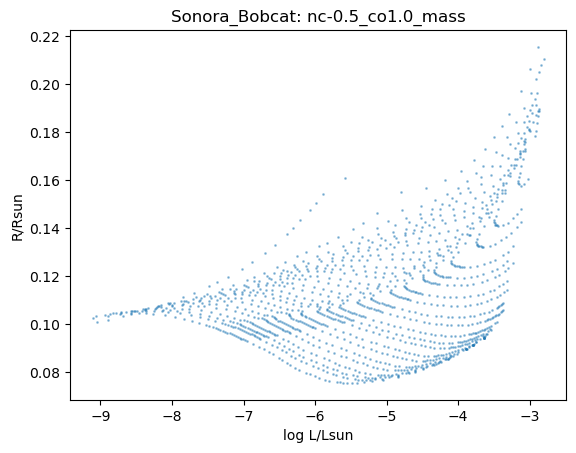

In [13]:
# quick visual check of the (logL, radius) plane used for interpolation
plt.scatter(out_grid['logL'], out_grid['radius'], s=1, alpha=0.4)
plt.xlabel('log L/Lsun')
plt.ylabel('R/Rsun')
plt.title(f'{model}: {filename}')

## 5. Explore `seda.models.EvolutionaryModels(MY_MODEL)`

**Now we can explore the object `seda.models.EvolutionaryModels(MY_MODEL)`.**

In [14]:
# tables discovered via config.json filename_pattern
seda.models.EvolutionaryModels(model).available_tables

['nc+0.0_co1.0_mass', 'nc+0.5_co1.0_mass', 'nc-0.5_co1.0_mass']

Accessing a few metadata fields:

In [15]:
# publication reference
seda.models.EvolutionaryModels(model).ref

'Marley et al. (2021)'

In [16]:
# column units declared in config.json (also shown in evol_params verbose output)
seda.models.EvolutionaryModels(model).units

{'mass': 'M_sun',
 'age': 'Gyr',
 'logL': 'log10(L/Lsun)',
 'Teff': 'K',
 'logg': 'cgs dex',
 'radius': 'R_sun'}

**Run `evol_params` on the new model**

In [17]:
# observables passed by the user (Lbol and R in Lsun / Rjup for Sonora models)
Lbol, eLbol = 6.324e-5, 6.978e-6  # Lsun
R, eR = 1.018, 0.059              # Rjup

# infer mass, age, Teff, logg by interpolating the evolutionary grid
seda.phy_params.evol_params(
    Lbol=Lbol, eLbol=eLbol, R=R, eR=eR,
    model=model,              # must match config.json "model" key
    filename=filename,        # required when multiple tables are bundled; omit if only one table
    verbose=True,             # prints inferred parameters and out-of-grid sample fraction
)

6/10000 (0.1%) Monte Carlo samples fell outside the evolutionary grid and were excluded from the statistics.

Inferred fundamental parameters (Sonora Bobcat, nc-0.5_co1.0_mass):
   mass = 0.03617 (-0.007679, +0.009099) M_sun
   age = 0.3563 (-0.1456, +0.2325) Gyr
   Teff = 1594 (-61.69, +65.23) K
   logg = 4.929 (-0.1505, +0.1598) cgs dex


{'mass': 0.03617097650175449,
 'emass': (0.007679136307806828, 0.00909883725120409),
 'age': 0.35625679600572807,
 'eage': (0.14555932089123153, 0.2324896138812908),
 'Teff': 1593.9747144103567,
 'eTeff': (61.694709494367544, 65.23296359056417),
 'logg': 4.929147259518075,
 'elogg': (0.15054437294267498, 0.15976344123809572),
 'n_outside_grid': 6,
 'frac_outside_grid': 0.0006}

### Notes for model authors

- Overlapping evolutionary tracks can give duplicate `(logL, radius)` pairs with different ages. Interpolation may blend tracks in degenerate regions.
- Both `_read_evolutionary_model` and `_convert_inputs` are required in every evolutionary plugin.
- After adding a folder under `evolution_aux/`, restart Python (or reload the package) so the registry picks up the new model.
- See also the atmospheric-model tutorial: `tutorial_ingest_new_models.ipynb`.